In [87]:
from hcipy import *
from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import time
import os
import sys
import pandas as pd
import utils

set the telescope and optics pramaters

In [ ]:
utils.check_dir
wavelength=1.55e-6
telescope_diameter=0.3
N=240
oversz=16.0/15.0
oversz*N
spider_w = 0.005         # [m]
D_obs =0.1       # [m]
eps = D_obs / telescope_diameter # central obscuration ratio
pupil_grid = make_pupil_grid(N*oversz, telescope_diameter * oversz)
ap_gen = make_obstructed_circular_aperture(telescope_diameter, eps, num_spiders=4, spider_width=spider_w)
ap = evaluate_supersampled(ap_gen, pupil_grid, 4) 
spatial_resolution=spatial_resolution = wavelength / telescope_diameter
num_airy_focal=5
focal_grid = make_focal_grid(q=4, num_airy=num_airy_focal, spatial_resolution=spatial_resolution)
prop = FraunhoferPropagator(pupil_grid, focal_grid)
aperture = make_circular_aperture(telescope_diameter)(pupil_grid)

In [89]:
fried_parameter = 0.2 # meter
outer_scale = 20 # meter
velocity = 10 # meter/sec


Cn_squared = Cn_squared_from_fried_parameter(fried_parameter, 500e-9)
layer = InfiniteAtmosphericLayer(pupil_grid, Cn_squared, outer_scale, velocity)

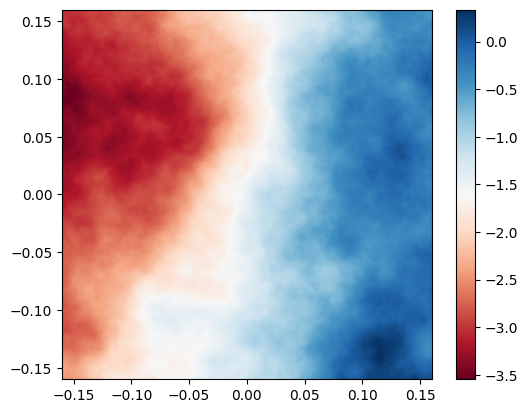

In [90]:
prop = FraunhoferPropagator(pupil_grid, focal_grid)
imshow_field(layer.phase_for(wavelength), cmap='RdBu')
plt.colorbar()
plt.show()

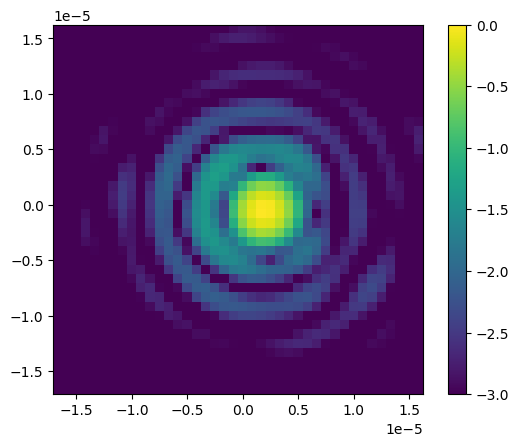

In [91]:

wf = Wavefront(aperture, wavelength)
img = prop(layer(wf))

imshow_field(np.log10(img.intensity / img.intensity.max()), vmin=-3)
plt.colorbar()
plt.show()

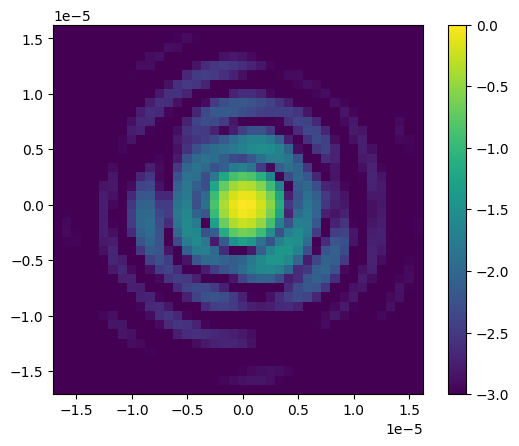

In [92]:
layer.t = 0.1 # sec

img = prop(layer(wf))

imshow_field(np.log10(img.intensity / img.intensity.max()), vmin=-3)
plt.colorbar()
plt.show()

6.948748147203085e-13


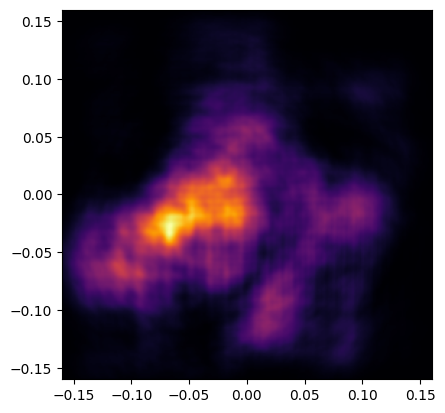

In [93]:
# Set the seeing parameters and reset
atmos.Cn_squared = Cn_squared_from_fried_parameter(0.1, 500e-9)
atmos.reset()
print(atmos.Cn_squared)
# Use super-Gaussian to avoid edge effects
p = np.exp(-(pupil_grid.as_('polar').r/0.68)**20)
wf = atmos(Wavefront(Field(p, pupil_grid), 2e-6))

# Show scintillation field
imshow_field(wf.intensity , cmap='inferno')
plt.show()

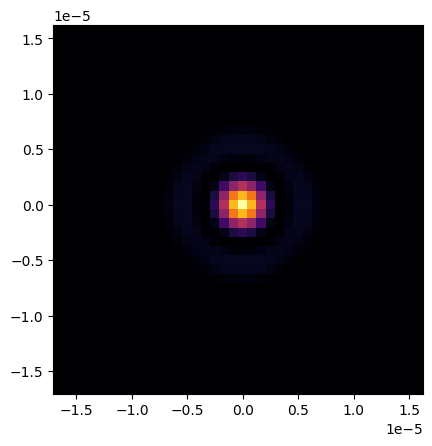

In [94]:
wf11=Wavefront(ap,wavelength)
imshow_field(prop(wf11).intensity , cmap='inferno')



Layer 0: $C_n^2$ = 2.322e-12, velocity = [14.  0.]
Layer 1: $C_n^2$ = 8.979e-13, velocity = [14.  0.]
Layer 2: $C_n^2$ = 6.773e-13, velocity = [14.  0.]
Layer 3: $C_n^2$ = 1.483e-12, velocity = [14.  0.]
Layer 4: $C_n^2$ = 3.407e-12, velocity = [14.  0.]
Layer 5: $C_n^2$ = 1.373e-12, velocity = [14.  0.]
✅ Saved multi_layer_phase.mp4
✅ Saved multi_layer_intensity.mp4


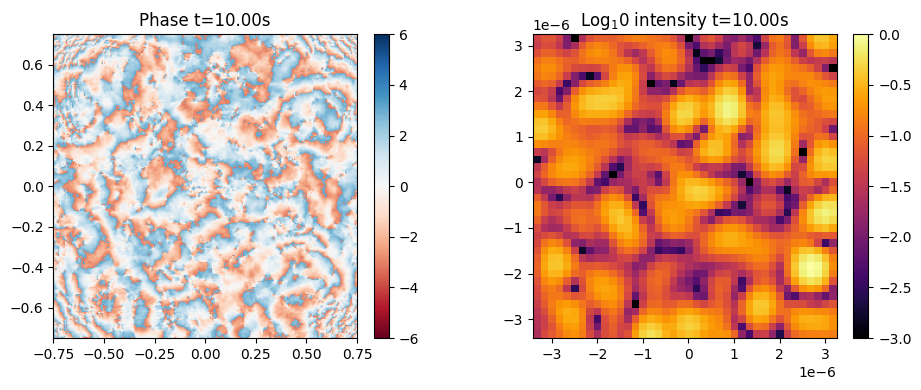

In [95]:
# Multi-layer atmosphere: dedicated phase and intensity animations
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter

anim_duration = 10.0  # seconds
fps = 10
num_frames = int(anim_duration * fps)

target_r0 = 0.035  # 3.5 cm Fried parameter target (specified at 1.55 µm)
cn2_scale = 1e-13
phase_vmin = -np.pi
phase_vmax = np.pi

wlen_anim = wavelength  # reuse wavelength from earlier cells

# Grids (decoupled from earlier cells to avoid shape mismatch)
pupil_grid_anim = make_pupil_grid(256, 1.5)
spatial_resolution_anim = wlen_anim / 1.5
focal_grid_anim = make_focal_grid(q=4, num_airy=num_airy_focal, spatial_resolution=spatial_resolution_anim)
prop_anim = FraunhoferPropagator(pupil_grid_anim, focal_grid_anim)

# Pupil / wavefront
pupil_ap_anim = make_circular_aperture(1.5)(pupil_grid_anim)
wf0_anim = Wavefront(pupil_ap_anim, wlen_anim)
wf0_anim.total_power = 1.0

total_cn2 = Cn_squared_from_fried_parameter(target_r0)
layers_anim = make_mauna_kea_atmospheric_layers(pupil_grid_anim, cn_squared=total_cn2, outer_scale=outer_scale)
for i, layer in enumerate(layers_anim):
    vel = getattr(layer, "velocity", None)
    print(f"Layer {i}: $C_n^2$ = {layer.Cn_squared:.3e}, velocity = {vel}")

layer_annotations = []
for i, layer in enumerate(layers_anim):
    vel = getattr(layer, "velocity", None)
    if vel is None:
        vel_str = "N/A"
    else:
        vel_value = float(np.asarray(vel).ravel()[0])
        vel_str = f"{vel_value:.1f} m/s"
    layer_annotations.append(f"Layer {i}: C_n^2={layer.Cn_squared / cn2_scale:.2f} x10^-13, v={vel_str}")
atmos_anim = MultiLayerAtmosphere(layers_anim, scintillation=True)


def render_single_quantity_animation(atmosphere, base_wavefront, propagator, *, quantity, fps, duration, filepath, title, cmap, vmin=None, vmax=None, log_floor=1e-12, annotation_lines=None, colorbar_label=None):
    if quantity not in {"phase", "intensity"}:
        raise ValueError(f"Unsupported quantity '{quantity}'")

    writer = FFMpegWriter(fps=fps)
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    times = np.linspace(0, duration, int(duration * fps), endpoint=False)

    if hasattr(atmosphere, 'reset'):
        atmosphere.reset()
    atmosphere.t = 0.0
    with writer.saving(fig, filepath, dpi=150):
        for t in times:
            atmosphere.t = t
            wf_after = atmosphere(base_wavefront)

            if quantity == "phase":
                phase_values = np.angle(np.asarray(wf_after.electric_field))
                phase_wrapped = ((phase_values + np.pi) % (2 * np.pi)) - np.pi
                field = Field(phase_wrapped, wf_after.electric_field.grid)
            else:
                img = propagator(wf_after)
                intensity_field = img.intensity
                max_val = np.max(intensity_field)
                if max_val == 0:
                    max_val = 1.0
                norm = np.asarray(intensity_field) / max_val
                norm = np.clip(norm, log_floor, None)
                field = Field(np.log10(norm), intensity_field.grid)

            ax.clear()
            im = imshow_field(field, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax)
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            if colorbar_label:
                cbar.set_label(colorbar_label)
            ax.set_title(f"{title} t={t:.2f}s")
            if annotation_lines:
                annotation_text = "\n".join(annotation_lines)
                ax.text(0.02, 0.02, annotation_text, transform=ax.transAxes, fontsize=9, color='white',
                        ha='left', va='bottom', bbox=dict(facecolor='black', alpha=0.4, pad=3, edgecolor='none'))
            plt.tight_layout()
            writer.grab_frame()
            cbar.remove()

    plt.close(fig)
    print(f"✅ Saved {filepath}")


render_single_quantity_animation(
    atmos_anim,
    wf0_anim,
    prop_anim,
    quantity="phase",
    fps=fps,
    duration=anim_duration,
    filepath="multi_layer_phase.mp4",
    title="Multi-layer phase",
    cmap="RdBu",
    vmin=phase_vmin,
    vmax=phase_vmax,
    annotation_lines=layer_annotations,
    colorbar_label="Phase [rad]",
)

render_single_quantity_animation(
    atmos_anim,
    wf0_anim,
    prop_anim,
    quantity="intensity",
    fps=fps,
    duration=anim_duration,
    filepath="multi_layer_intensity.mp4",
    title="Multi-layer log$_{10}$ intensity",
    cmap="inferno",
    vmin=-3,
    vmax=0,
    annotation_lines=layer_annotations,
    colorbar_label="log10 intensity",
)

# Show one representative frame inline (fresh atmosphere to avoid backward time evolution)
layers_anim_preview = make_mauna_kea_atmospheric_layers(pupil_grid_anim, cn_squared=total_cn2, outer_scale=outer_scale)
atmos_anim_preview = MultiLayerAtmosphere(layers_anim_preview, scintillation=True)
atmos_anim_preview.t = anim_duration  # advance forward, no backward step
wf_after = atmos_anim_preview(wf0_anim)
phase_values = np.angle(np.asarray(wf_after.electric_field))
phase_wrapped = ((phase_values + np.pi) % (2 * np.pi)) - np.pi
phase_field = Field(phase_wrapped, wf_after.electric_field.grid)
img = prop_anim(wf_after)
intensity_field = img.intensity
max_preview = np.max(intensity_field)
if max_preview == 0:
    max_preview = 1.0
norm_preview = np.asarray(intensity_field) / max_preview
norm_preview = np.clip(norm_preview, 1e-12, None)
log_intensity_preview = Field(np.log10(norm_preview), intensity_field.grid)

fig, (ax_phase, ax_intensity) = plt.subplots(1, 2, figsize=(10, 4))
im_phase = imshow_field(phase_field, ax=ax_phase, cmap="RdBu", vmin=phase_vmin, vmax=phase_vmax)
fig.colorbar(im_phase, ax=ax_phase, fraction=0.046, pad=0.04)
ax_phase.set_title(f"Phase t={anim_duration:.2f}s")

im_int = imshow_field(log_intensity_preview, ax=ax_intensity, cmap="inferno", vmin=-3, vmax=0)
fig.colorbar(im_int, ax=ax_intensity, fraction=0.046, pad=0.04)
ax_intensity.set_title(f"Log$_{10}$ intensity t={anim_duration:.2f}s")
plt.tight_layout()
plt.show()


Ground layer: $C_n^2$ = 2.322e-12, velocity = [14.  0.]
✅ Saved ground_layer_phase.mp4
✅ Saved ground_layer_intensity.mp4


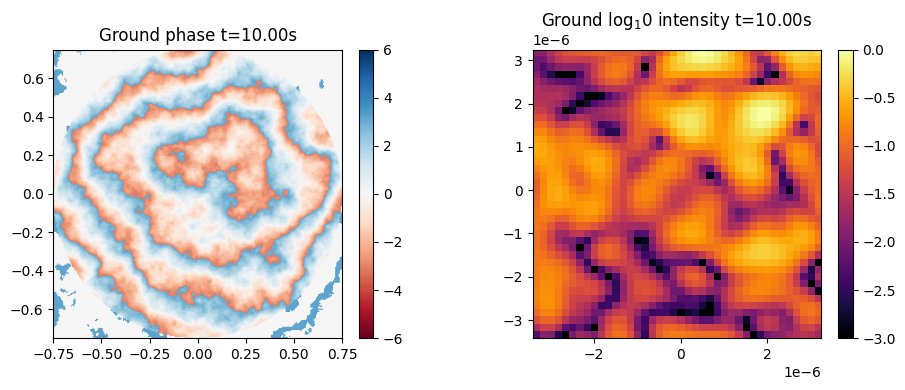

In [96]:
# Ground-layer-only atmosphere: dedicated phase and intensity animations
# Reuse the grids defined above
pupil_grid_ground = pupil_grid_anim
prop_ground = prop_anim

# Single ground layer (use first layer parameters as example)
ground_Cn2 = layers_anim[0].Cn_squared
try:
    ground_vel = layers_anim[0].velocity
except AttributeError:
    ground_vel = None

layer_ground = InfiniteAtmosphericLayer(pupil_grid_ground, ground_Cn2, outer_scale, ground_vel)
atmos_ground = MultiLayerAtmosphere([layer_ground], scintillation=True)
print(f"Ground layer: $C_n^2$ = {ground_Cn2:.3e}, velocity = {ground_vel}")

if ground_vel is None:
    ground_vel_str = "N/A"
else:
    ground_vel_value = float(np.asarray(ground_vel).ravel()[0])
    ground_vel_str = f"{ground_vel_value:.1f} m/s"
ground_annotation = [f"Ground layer C_n^2={ground_Cn2 / cn2_scale:.2f} x10^-13, v={ground_vel_str}"]

render_single_quantity_animation(
    atmos_ground,
    wf0_anim,
    prop_ground,
    quantity="phase",
    fps=fps,
    duration=anim_duration,
    filepath="ground_layer_phase.mp4",
    title="Ground-layer phase",
    cmap="RdBu",
    vmin=phase_vmin,
    vmax=phase_vmax,
    annotation_lines=ground_annotation,
    colorbar_label="Phase [rad]",
)

render_single_quantity_animation(
    atmos_ground,
    wf0_anim,
    prop_ground,
    quantity="intensity",
    fps=fps,
    duration=anim_duration,
    filepath="ground_layer_intensity.mp4",
    title="Ground-layer log$_{10}$ intensity",
    cmap="inferno",
    vmin=-3,
    vmax=0,
    annotation_lines=ground_annotation,
    colorbar_label="log10 intensity",
)

# Show one representative frame inline (fresh ground atmosphere to avoid backward time)
layer_ground_preview = InfiniteAtmosphericLayer(pupil_grid_ground, ground_Cn2, outer_scale, ground_vel)
atmos_ground_preview = MultiLayerAtmosphere([layer_ground_preview], scintillation=True)
atmos_ground_preview.t = anim_duration  # forward only
wf_after = atmos_ground_preview(wf0_anim)
phase_values = np.angle(np.asarray(wf_after.electric_field))
phase_wrapped = ((phase_values + np.pi) % (2 * np.pi)) - np.pi
phase_field = Field(phase_wrapped, wf_after.electric_field.grid)
img = prop_ground(wf_after)
intensity_field = img.intensity
max_preview = np.max(intensity_field)
if max_preview == 0:
    max_preview = 1.0
norm_preview = np.asarray(intensity_field) / max_preview
norm_preview = np.clip(norm_preview, 1e-12, None)
log_intensity_preview = Field(np.log10(norm_preview), intensity_field.grid)

fig, (ax_phase, ax_intensity) = plt.subplots(1, 2, figsize=(10, 4))
im_phase = imshow_field(phase_field, ax=ax_phase, cmap="RdBu", vmin=phase_vmin, vmax=phase_vmax)
fig.colorbar(im_phase, ax=ax_phase, fraction=0.046, pad=0.04)
ax_phase.set_title(f"Ground phase t={anim_duration:.2f}s")

im_int = imshow_field(log_intensity_preview, ax=ax_intensity, cmap="inferno", vmin=-3, vmax=0)
fig.colorbar(im_int, ax=ax_intensity, fraction=0.046, pad=0.04)
ax_intensity.set_title(f"Ground log$_{10}$ intensity t={anim_duration:.2f}s")
plt.tight_layout()
plt.show()


In [97]:
from IPython.display import Video, display
display(Video('multi_layer_phase.mp4', embed=True, html_attributes='controls loop'))
display(Video('multi_layer_intensity.mp4', embed=True, html_attributes='controls loop'))


In [ ]:
from IPython.display import Video, display
display(Video('ground_layer_phase.mp4', embed=True, html_attributes='controls loop'))
display(Video('ground_layer_intensity.mp4', embed=True, html_attributes='controls loop'))
